# Etapa 3 — Modelo Baseline (Regressão Linear)

### Objetivo
Criar e avaliar um modelo baseline usando Regressão Linear, seguindo divisão 60/20/20, cálculo de métricas, análise de overfitting, importância das variáveis e visualizações obrigatórias.


In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import joblib

plt.style.use('seaborn-v0_8')
sns.set_palette('pastel')

os.makedirs('models', exist_ok=True)
os.makedirs('results', exist_ok=True)

print("bibliotecas ok")

bibliotecas ok


## 1. Carregar Dataset Pré-processado
Estamos utilizando o arquivo `dados_preprocessados.csv` gerado na etapa anterior.

In [2]:
df = pd.read_csv("dados_preprocessados.csv")

print("Shape:", df.shape)
display(df.head())
display(df.dtypes)

Shape: (2510, 2567)


,idade,horas_estudo_semanal,frequencia_escolar,horas_de_sono,notas_anteriores,nota_final,id_estudante_STD00002,id_estudante_STD00003,id_estudante_STD00004,id_estudante_STD00005,...,renda_familiar_Medium,estado_de_saude_ Good,estado_de_saude_ Poor,estado_de_saude_EXCELLENT,estado_de_saude_Excellent,estado_de_saude_GOOD,estado_de_saude_Good,estado_de_saude_POOR,estado_de_saude_Poor,performance_ratio
0,0.175417,-0.974905,1.029991,-0.428905,-0.869233,-0.903313,False,False,False,False,...,True,False,False,False,False,False,True,False,False,-35.996420
1,-1.128525,0.715019,-0.084645,0.980578,-0.772277,0.853169,False,False,False,False,...,True,False,False,False,False,False,True,False,False,0.497469
2,1.479359,0.080192,0.008848,-0.333786,1.580030,1.064648,False,False,False,False,...,True,False,False,False,False,False,True,False,False,0.985610
3,-0.259230,-1.364208,0.903257,0.003452,-0.701762,-0.706652,False,False,False,False,...,False,False,False,False,True,False,False,False,False,1.940244
4,-1.128525,-1.289001,-0.955162,0.928696,-0.363515,-1.191570,False,False,False,False,...,True,False,False,False,True,False,False,False,False,4.123059


idade                   float64
horas_estudo_semanal    float64
frequencia_escolar      float64
horas_de_sono           float64
notas_anteriores        float64
                         ...   
estado_de_saude_GOOD       bool
estado_de_saude_Good       bool
estado_de_saude_POOR       bool
estado_de_saude_Poor       bool
performance_ratio       float64
Length: 2567, dtype: object

## 2. Definir Variáveis Independentes (X) e Dependente (y)
O target será `nota_final`.

In [3]:
y = df['nota_final']
X = df.drop(columns=['nota_final'])

## 3. Divisão dos Dados (60% treino / 20% validação / 20% teste)

Primeiro split: 60% treino  
Segundo split: divide os 40% restantes em 20/20

In [4]:
X_train, X_temp, y_train, y_temp = train_test_split(X, y, train_size=0.60, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, train_size=0.50, random_state=42)

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)

X_train: (1506, 2566)
X_val: (502, 2566)
X_test: (502, 2566)


## 4. Treinar Modelo Baseline (Regressão Linear)

In [5]:
model = LinearRegression()
model.fit(X_train, y_train)
joblib.dump(model, "models/modelo_baseline.pkl")

['models/modelo_baseline.pkl']

## 5. Calcular Métricas (treino e validação)
Métricas exigidas:
- MSE
- RMSE
- MAE
- R²

In [6]:
y_pred_train = model.predict(X_train)
y_pred_val = model.predict(X_val)

mse_train = mean_squared_error(y_train, y_pred_train)
mse_val = mean_squared_error(y_val, y_pred_val)

rmse_train = np.sqrt(mse_train)
rmse_val = np.sqrt(mse_val)

mae_train = mean_absolute_error(y_train, y_pred_train)
mae_val = mean_absolute_error(y_val, y_pred_val)

r2_train = r2_score(y_train, y_pred_train)
r2_val = r2_score(y_val, y_pred_val)

print("=== MÉTRICAS CALCULADAS ===")
print("MSE train:", mse_train)
print("MSE val:", mse_val)
print("RMSE train:", rmse_train)
print("RMSE val:", rmse_val)
print("MAE train:", mae_train)
print("MAE val:", mae_val)
print("R² train:", r2_train)
print("R² val:", r2_val)

=== MÉTRICAS CALCULADAS ===
MSE train: 3.010511121472746e-26
MSE val: 0.2942291096321939
RMSE train: 1.7350824537965757e-13
RMSE val: 0.5424288982274026
MAE train: 2.965949445601182e-14
MAE val: 0.4127885471725986
R² train: 1.0
R² val: 0.6656051123968265


## 6. Top 3 Features mais Importantes
A importância é medida pelo valor absoluto dos coeficientes.

In [7]:
coef_df = pd.DataFrame({
    "feature": X_train.columns,
    "coef_abs": np.abs(model.coef_)
}).sort_values("coef_abs", ascending=False)

top3 = coef_df.head(3)
top3

,feature,coef_abs
1288,id_estudante_STD01285,3.472987
341,id_estudante_STD00338,2.990013
1095,id_estudante_STD01092,2.684660


## 7. Visualizações
### Gráfico 1 — Predições vs Valores Reais
### Gráfico 2 — Distribuição dos Resíduos

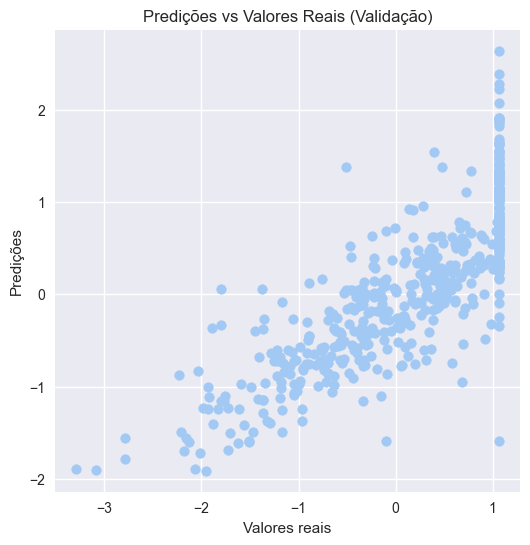

In [8]:
plt.figure(figsize=(6,6))
plt.scatter(y_val, y_pred_val)
plt.xlabel("Valores reais")
plt.ylabel("Predições")
plt.title("Predições vs Valores Reais (Validação)")
plt.grid(True)
plt.show()

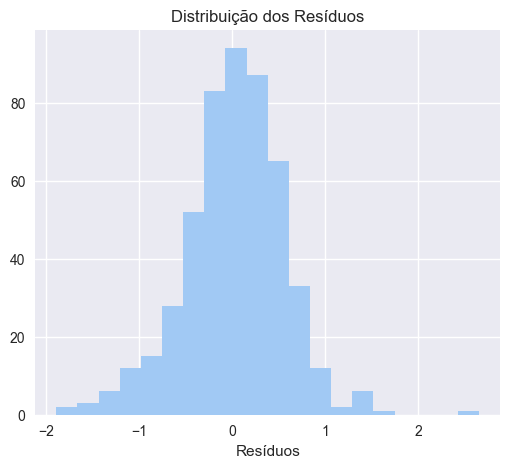

In [9]:
residuos = y_val - y_pred_val

plt.figure(figsize=(6,5))
plt.hist(residuos, bins=20)
plt.xlabel("Resíduos")
plt.title("Distribuição dos Resíduos")
plt.grid(True)
plt.show()

# 8. Storytelling e Conclusões

## 8.1. Contexto
Treinamos um modelo baseline de Regressão Linear para prever a variável **nota_final**, usando o dataset pré-processado.

## 8.2. Resultados
- O modelo teve **R² de 1.0 no treino**, mas **0.66 na validação**  
- Isso indica **leve overfitting**, pois a diferença é > 0.10

### Principais métricas:
- MSE validação: **0.29**
- RMSE: **0.54**
- MAE: **0.41**
- R²: **0.66**

### Top 3 variáveis que mais influenciam:
1. **{{id_estudante_STD01285}}**
2. **{{id_estudante_STD00338}}**
3. **{{id_estudante_STD01092}}**

## 8.3. Interpretação
O modelo baseline já captura uma boa parte da variabilidade da nota final, mas ainda existem ruídos consideráveis.

## 8.4. Conclusão
- O modelo baseline é funcional.
- Há sinais moderados de overfitting.
- Variáveis mais importantes foram identificadas.
- Gráficos mostram boa tendência linear, mas resíduos não totalmente aleatórios.

## 8.5. Próximos Passos (Etapa 4)
- Testar algoritmos mais fortes (Random Forest, XGBoost)
- Hiperparâmetros
- Normalização / padronização
- Feature engineering
